In [1]:
#import packages
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, image
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

In [ ]:
BASE_DIR     = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")
SUBJECT      = 100206
TASK         = "EMOTION"     # 또는 "EMOTION"
PHASE        = "LR"          # "LR" 또는 "RL"
WINDOW_SIZE  = 24            # TR 단위
STEP_SIZE    = 3             # TR 단위

C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\938647361.py:30: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\938647361.py:30: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\938647361.py:30: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\938647361.py:30: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\938647361.py:30: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\938647361.py:30: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from fo

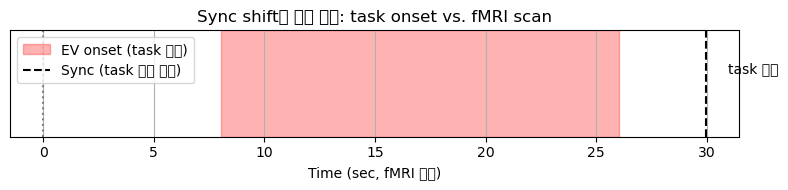

In [21]:
import matplotlib.pyplot as plt
import numpy as np

TR = 0.72
sync_shift = 29.955

# Example EV (task 기준): fear starts at 8.032s, lasts 18s
ev_onset = 8.032
ev_duration = 18

# fMRI scan 기준으로 환산
fmri_onset = ev_onset - sync_shift  # fMRI scan이 시작되기 전이면 음수로 나옴

# 시각화
plt.figure(figsize=(8, 2))
plt.axvspan(ev_onset, ev_onset + ev_duration, color='red', alpha=0.3, label="EV onset (task 기준)")
if fmri_onset >= 0:
    plt.axvspan(fmri_onset, fmri_onset + ev_duration, color='blue', alpha=0.3, label="fMRI 기준 onset")
else:
    plt.axvline(sync_shift, color='black', linestyle='--', label='Sync (task 시작 시점)')
    plt.text(sync_shift + 1, 0.6, 'task 시작', color='black')

plt.axvline(0, color='gray', linestyle='dotted')
plt.xlabel("Time (sec, fMRI 기준)")
plt.yticks([])
plt.ylim(0, 1)
plt.title("Sync shift의 실제 의미: task onset vs. fMRI scan")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
import pandas as pd

# ───────────────
# Task Parameters
# ───────────────
TR         = 0.72
SYNC_SHIFT = 29.955   # Emotion LR의 Sync.txt에서 추출
WINDOW_SIZE = 24
STEP_SIZE   = 3
ORIGINAL_T  = 176     # ts_resid.shape[0] 기준

# ───────────────
# Raw block data (from EVs of Emotion LR)
# Format: (label, onset, duration)
# ───────────────
raw_blocks = [
    ("fear",      8.032, 18.0),
    ("neutral",  30.996, 18.0),
    ("fear",     54.000, 18.0),
    ("neutral",  76.952, 18.0),
    ("fear",     99.971, 18.0),
    ("neutral", 122.966, 18.0),
]

# ───────────────
# 1. Apply Sync shift to compute block TR range
# ───────────────
events = []
for label, onset, duration in raw_blocks:
    shifted_onset = onset - SYNC_SHIFT
    if shifted_onset < 0:
        continue
    start_tr = int(np.floor(shifted_onset / TR))
    end_tr   = int(np.ceil((shifted_onset + duration) / TR)) - 1
    events.append({
        "trial_type": label,
        "onset_sec":  shifted_onset,
        "duration_s": duration,
        "start_tr":   start_tr,
        "end_tr":     end_tr
    })

ev_df = pd.DataFrame(events)
print("\n=== BLOCKS AFTER SYNC SHIFT ===")
print(ev_df[["trial_type", "start_tr", "end_tr"]].to_string(index=False))

# ───────────────
# 2. Sliding Window Labeling (based on ts_resid of length 253)
# ───────────────
T = ORIGINAL_T
n_windows = (T - WINDOW_SIZE) // STEP_SIZE + 1

window_labels = []
for t in range(n_windows):
    center_tr = t * STEP_SIZE + (WINDOW_SIZE // 2)
    hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
    window_labels.append(hit.iloc[0]["trial_type"] if not hit.empty else "no_event")

win_df = pd.DataFrame({
    "window_index": np.arange(n_windows),
    "center_tr":    np.arange(n_windows) * STEP_SIZE + (WINDOW_SIZE // 2),
    "block_label":  window_labels
})

print("\n=== WINDOW LABELS ===")
print(win_df.to_string(index=False))



=== BLOCKS AFTER SYNC SHIFT ===
trial_type  start_tr  end_tr
   neutral         1      26
      fear        33      58
   neutral        65      90
      fear        97     122
   neutral       129     154

=== WINDOW LABELS ===
 window_index  center_tr block_label
            0         12     neutral
            1         15     neutral
            2         18     neutral
            3         21     neutral
            4         24     neutral
            5         27    no_event
            6         30    no_event
            7         33        fear
            8         36        fear
            9         39        fear
           10         42        fear
           11         45        fear
           12         48        fear
           13         51        fear
           14         54        fear
           15         57        fear
           16         60    no_event
           17         63    no_event
           18         66     neutral
           19         69     n

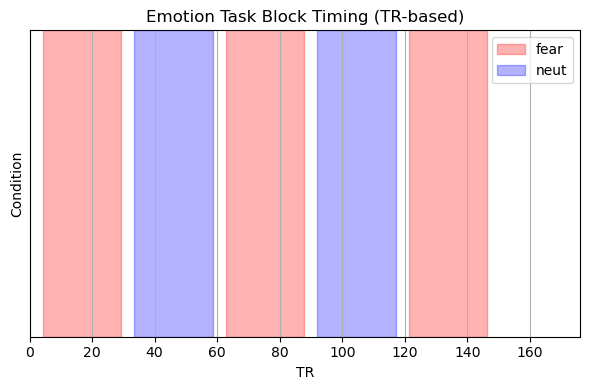

In [19]:
import matplotlib.pyplot as plt

TR = 0.72

# 원래 초 단위로 쓰던 onset들을 TR 단위로 변환
blocks = [
    ("fear", 3.074, "red"),
    ("neut", 24.145, "blue"),
    ("fear", 45.217, "red"),
    ("neut", 66.288, "blue"),
    ("fear", 87.359, "red"),
]

plt.figure(figsize=(6, 4))

for label, onset_sec, color in blocks:
    onset_tr = onset_sec / TR
    duration_tr = 18 / TR  # block duration = 18s → 25 TR
    label_text = label if label not in plt.gca().get_legend_handles_labels()[1] else ""
    plt.axvspan(onset_tr, onset_tr + duration_tr, color=color, alpha=0.3, label=label_text)

plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Emotion Task Block Timing (TR-based)")
plt.xlim(0, 176)
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\2659347827.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\JINHWA\AppData\Local\Temp\ipykernel_10188\2659347827.py:33: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


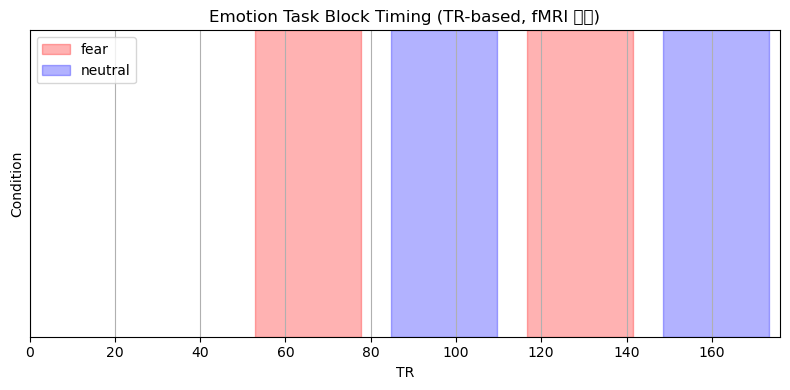

In [22]:
import matplotlib.pyplot as plt

TR = 0.72
sync_shift = 29.955

# EV onset 기준 (stimulus 기준)
raw_blocks = [
    ("fear",   8.032, "red"),
    ("neutral",30.996, "blue"),
    ("fear",   54.000, "red"),
    ("neutral",76.952, "blue"),
    ("fear",   99.971, "red"),
]

plt.figure(figsize=(8, 4))

for label, onset_sec, color in raw_blocks:
    # ✅ fMRI 기준으로 shift: onset + sync
    fmri_onset_sec = onset_sec + sync_shift
    fmri_onset_tr = fmri_onset_sec / TR
    duration_tr = 18 / TR  # 18s → 25 TR

    label_text = label if label not in plt.gca().get_legend_handles_labels()[1] else ""
    plt.axvspan(fmri_onset_tr, fmri_onset_tr + duration_tr, color=color, alpha=0.3, label=label_text)

plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Emotion Task Block Timing (TR-based, fMRI 기준)")
plt.xlim(0, 176)
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
aal = datasets.fetch_atlas_aal()
aal_img    = aal.maps    # AAL atlas NIfTI 경로
aal_labels = aal.labels  # ROI 이름 리스트

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [5]:
masker    = NiftiLabelsMasker(
    labels_img       = aal_img,
    standardize      = "zscore_sample",
    detrend          = True,
    low_pass         = None,
    high_pass        = None,
    t_r              = 0.72,
    resampling_target = "data"
)

In [6]:
def make_paths(subject, task, phase="LR"):
    img_path = BASE_DIR / f"{subject:06d}/MNINonLinear/Results/tfMRI_{task}_{phase}/tfMRI_{task}_{phase}.nii.gz"
    ev_dir   = img_path.parent / "EVs"
    return img_path, ev_dir

In [7]:
def get_residual(img_path: Path, ev_dir: Path):
    """
    EVs 폴더 내의 *.txt 파일들을 건너뛰기 로직과 함께 읽어서
    onset/duration 정보를 모은 뒤, FirstLevelModel로 GLM을 수행한 후
    residual 4D 이미지를 반환합니다.
    """
    events = []

    for ev_file in sorted(ev_dir.glob("*.txt")):
        # 1) 순수히 숫자가 아닌 파일은 건너뛰기
        try:
            data = np.loadtxt(ev_file)
        except Exception:
            continue

        # 2) 빈 파일 혹은 숫자가 0개라면 건너뜀
        if data.size == 0:
            continue

        # 3) 1차원 배열(단일 행)인 경우, 열 개수 확인
        if data.ndim == 1:
            if data.shape[0] < 2:
                # onset/duration 정보를 담기 어렵다면 건너뜀
                continue
            data = data.reshape(1, -1)

        # 4) 2차원 배열(여러 행)인 경우, 열 개수가 2 또는 3인지 확인
        if data.ndim == 2:
            n_cols = data.shape[1]
            if n_cols not in (2, 3):
                continue
        else:
            # ndim이 0 또는 3 이상이면 건너뜀
            continue

        # 5) 최종적으로 data가 (N_events, 2) 혹은 (N_events, 3) 모양으로 보장됨
        if data.shape[1] == 3:
            onset_arr, duration_arr, _ = data.T
        else:  # data.shape[1] == 2
            onset_arr, duration_arr = data.T

        for o, d in zip(onset_arr, duration_arr):
            events.append({
                "onset":      float(o),
                "duration":   float(d),
                "trial_type": ev_file.stem
            })

    # 만약 events 리스트가 비어 있으면 None 반환
    if not events:
        return None

    # 이벤트가 모였다면 DataFrame으로 정리하고 GLM → residual 반환
    events_df = pd.DataFrame(events, columns=["onset", "duration", "trial_type"])
    fmri_img  = image.load_img(str(img_path))
    model     = FirstLevelModel(
        t_r              = 0.72,
        drift_model      = "polynomial",
        standardize      = False,
        minimize_memory  = False
    ).fit(fmri_img, events=events_df)

    return model.residuals[0]  # list이므로 첫 번째 residual 4D 이미지 반환

In [8]:
def sliding_window_dist(ts: np.ndarray, win: int, step: int) -> np.ndarray:
    """
    ts: (T, P) shaped array, T = time points, P = number of ROIs
    win: window length in TRs
    step: sliding step in TRs

    반환값: (n_windows, P, P) shaped array of 1 - |correlation| distance matrices
    """
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P        = ts.shape
    n_windows   = (T - win) // step + 1
    out         = np.zeros((n_windows, P, P), dtype=np.float32)

    for idx, start in enumerate(range(0, T - win + 1, step)):
        segment      = ts[start : start + win]
        corr_matrix  = connectivity.fit_transform([segment])[0]
        dist_matrix  = 1.0 - np.abs(corr_matrix)
        out[idx]     = dist_matrix

    return out

In [9]:
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts")
OUT_DIR.mkdir(exist_ok=True)

In [10]:
img_path, ev_dir = make_paths(SUBJECT, TASK, PHASE)
print(f"Loading {TASK} {PHASE} run from: {img_path}")

Loading EMOTION LR run from: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\100206\MNINonLinear\Results\tfMRI_EMOTION_LR\tfMRI_EMOTION_LR.nii.gz


In [11]:
resid_img = get_residual(img_path, ev_dir)
if resid_img is None:
    raise RuntimeError(f"No usable EV files found for {TASK} {PHASE} run.")

c:\Users\JINHWA\miniconda3\envs\tda\Lib\site-packages\nilearn\glm\first_level\first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [12]:
ts_resid = masker.fit_transform(resid_img)   # shape = (T, n_rois)
T, n_rois = ts_resid.shape
print(f"Extracted time-series shape: {ts_resid.shape}")

Extracted time-series shape: (176, 116)


In [13]:
dist_tensor = sliding_window_dist(ts_resid, WINDOW_SIZE, STEP_SIZE)
print(f"Distance tensor shape: {dist_tensor.shape}")

Distance tensor shape: (36, 116, 116)
